In [315]:
#from google.colab import drive
#drive.mount('/content/drive')
#import os
#os.chdir('/content/drive/MyDrive/ML group project')

In [316]:
#!pip install sktime

In [37]:
import pandas as pd
import numpy as np
from sktime.forecasting.compose import EnsembleForecaster
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.forecasting.trend import PolynomialTrendForecaster
from sktime.forecasting.compose import make_reduction
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import time
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates


In [2]:
random_state = 42

# Preprocessing

## Offshore data

In [5]:
off_df = pd.read_csv("data/final_offshore_data_2017_2025.csv", dtype = {'year_mon_day':'int32'})
# Removing data from 2025
off_df = off_df[off_df['full_datetime'] < "2025-01-01-01"]

# Convert 'correct days' to datetype format for further processing
off_df[['date', 'hour']] = off_df['correct_days'].str.rsplit('-', n=1, expand=True)

off_df['hour'] = off_df['hour'].astype(int) - 1

off_df['datetime'] = pd.to_datetime(off_df['date']) + pd.to_timedelta(off_df['hour'], unit='h')

off_df.tail()
# Create a unique numerical index
#data['unique_id'] = range(1, len(data)+1)  # Ensuring uniqueness

off_df = off_df.drop(['year_mon_day', 'hour', 'full_datetime', 'capacity', 'emission', 'emissionfactor', 'percentage', 'date', 'correct_days', "wind_speed_h_avg"], axis = 1)

# Set datetime as index
off_df = off_df.set_index('datetime')

# Monthly averages
off_df_m = off_df.resample('M').mean()

# Weekly averages
off_df_w = off_df.resample('W').mean()
# Remove last row for 2025-01-05
off_df_w = off_df_w.iloc[:-1]

# Daily averages
off_df_d = off_df.resample('D').mean()

### Monthly data preprocessing

In [9]:
# Split data into target and exogenous variables
y_m = off_df_m['volume']
X_m = off_df_m.drop('volume', axis=1)  # All exogenous variables

# Create train/test split
y_train_off_m, y_test_off_m, X_train_off_m, X_test_off_m = temporal_train_test_split(y_m, X_m, test_size=0.0625)


# Define the preprocessor with feature names retained
preprocessor = StandardScaler()

# Fit and transform the data
X_train_norm = preprocessor.fit_transform(X_train_off_m)
X_test_norm = preprocessor.transform(X_test_off_m)

# Convert back to DataFrame with original column names
feature_names = preprocessor.get_feature_names_out()
X_train_off_m = pd.DataFrame(X_train_norm, columns=X_train_off_m.columns, index=X_train_off_m.index)
X_test_off_m = pd.DataFrame(X_test_norm, columns=X_test_off_m.columns, index=X_test_off_m.index)

### Weekly data preprocessing

In [11]:
# Split data into target and exogenous variables
y_w = off_df_w['volume']
X_w = off_df_w.drop('volume', axis=1)  # All exogenous variables

# Create train/test split
y_train_off_w, y_test_off_w, X_train_off_w, X_test_off_w = temporal_train_test_split(y_w, X_w, test_size=0.0287)

# Define the preprocessor with feature names retained
preprocessor = StandardScaler()

# Fit and transform the data
X_train_norm = preprocessor.fit_transform(X_train_off_w)
X_test_norm = preprocessor.transform(X_test_off_w)

# Convert back to DataFrame with original column names
feature_names = preprocessor.get_feature_names_out()
X_train_off_w = pd.DataFrame(X_train_norm, columns=X_train_off_w.columns, index=X_train_off_w.index)
X_test_off_w = pd.DataFrame(X_test_norm, columns=X_test_off_w.columns, index=X_test_off_w.index)

### Daily data preprocessing

In [13]:
# Split data into target and exogenous variables
y_d = off_df_d['volume']
X_d = off_df_d.drop('volume', axis=1)  # All exogenous variables

# Create train/test split
y_train_off_d, y_test_off_d, X_train_off_d, X_test_off_d = temporal_train_test_split(y_d, X_d, test_size=0.02053)

# Define the preprocessor with feature names retained
preprocessor = StandardScaler()

# Fit and transform the data
X_train_norm = preprocessor.fit_transform(X_train_off_d)
X_test_norm = preprocessor.transform(X_test_off_d)

# Convert back to DataFrame with original column names
feature_names = preprocessor.get_feature_names_out()
X_train_off_d = pd.DataFrame(X_train_norm, columns=X_train_off_d.columns, index=X_train_off_d.index)
X_test_off_d = pd.DataFrame(X_test_norm, columns=X_test_off_d.columns, index=X_test_off_d.index)

### Hourly data preprocessing

In [15]:
# Split data into target and exogenous variables
y_h = off_df['volume']
X_h = off_df.drop('volume', axis=1)  # All exogenous variables

# Create train/test split
y_train_off_h, y_test_off_h, X_train_off_h, X_test_off_h = temporal_train_test_split(y_h, X_h, test_size=0.00239)

# Define the preprocessor with feature names retained
preprocessor = StandardScaler()

# Fit and transform the data
X_train_norm = preprocessor.fit_transform(X_train_off_h)
X_test_norm = preprocessor.transform(X_test_off_h)

# Convert back to DataFrame with original column names
feature_names = preprocessor.get_feature_names_out()
X_train_off_h = pd.DataFrame(X_train_norm, columns=X_train_off_h.columns, index=X_train_off_h.index)
X_test_off_h = pd.DataFrame(X_test_norm, columns=X_test_off_h.columns, index=X_test_off_h.index)

## Onshore data

In [17]:
on_df = pd.read_csv("data/final_onshore_data_2017_2025.csv", dtype = {'year_mon_day':'int32'})
# Removing data from 2025
on_df = on_df[on_df['full_datetime'] < "2025-01-01-01"]

# Convert 'correct days' to datetype format for further processing
on_df[['date', 'hour']] = on_df['correct_days'].str.rsplit('-', n=1, expand=True)

on_df['hour'] = on_df['hour'].astype(int) - 1

on_df['datetime'] = pd.to_datetime(on_df['date']) + pd.to_timedelta(on_df['hour'], unit='h')

on_df.tail()
# Create a unique numerical index
#data['unique_id'] = range(1, len(data)+1)  # Ensuring uniqueness

on_df = on_df.drop(['year_mon_day', 'hour', 'full_datetime', 'capacity', 'emission', 'emissionfactor','percentage', 'date', 'correct_days',  'wind_speed_h_avg'], axis = 1)

# Set datetime as index
on_df = on_df.set_index('datetime')

# Monthly averages
on_df_m = on_df.resample('M').mean()

# Weekly averages
on_df_w = on_df.resample('W').mean()
# Remove last row for 2025-01-05
on_df_w = on_df_w.iloc[:-1]

# Daily averages
on_df_d = on_df.resample('D').mean()

### Monthly data preprocessing

In [19]:
# Split data into target and exogenous variables
y_m = on_df_m['volume']
X_m = on_df_m.drop('volume', axis=1)  # All exogenous variables

# Create train/test split
y_train_on_m, y_test_on_m, X_train_on_m, X_test_on_m = temporal_train_test_split(y_m, X_m, test_size=0.0625)


# Define the preprocessor with feature names retained
preprocessor = StandardScaler()

# Fit and transform the data
X_train_norm = preprocessor.fit_transform(X_train_on_m)
X_test_norm = preprocessor.transform(X_test_on_m)

# Convert back to DataFrame with original column names
feature_names = preprocessor.get_feature_names_out()
X_train_on_m = pd.DataFrame(X_train_norm, columns=X_train_on_m.columns, index=X_train_on_m.index)
X_test_on_m = pd.DataFrame(X_test_norm, columns=X_test_on_m.columns, index=X_test_on_m.index)

### Weekly data preprocessing

In [21]:
# Split data into target and exogenous variables
y_w = on_df_w['volume']
X_w = on_df_w.drop('volume', axis=1)  # All exogenous variables

# Create train/test split
y_train_on_w, y_test_on_w, X_train_on_w, X_test_on_w = temporal_train_test_split(y_w, X_w, test_size=0.0287)

# Define the preprocessor with feature names retained
preprocessor = StandardScaler()

# Fit and transform the data
X_train_norm = preprocessor.fit_transform(X_train_on_w)
X_test_norm = preprocessor.transform(X_test_on_w)

# Convert back to DataFrame with original column names
feature_names = preprocessor.get_feature_names_out()
X_train_on_w = pd.DataFrame(X_train_norm, columns=X_train_on_w.columns, index=X_train_on_w.index)
X_test_on_w = pd.DataFrame(X_test_norm, columns=X_test_on_w.columns, index=X_test_on_w.index)

### Daily data preprocessing

In [23]:
# Split data into target and exogenous variables
y_d = on_df_d['volume']
X_d = on_df_d.drop('volume', axis=1)  # All exogenous variables

# Create train/test split
y_train_on_d, y_test_on_d, X_train_on_d, X_test_on_d = temporal_train_test_split(y_d, X_d, test_size=0.02053)

# Define the preprocessor with feature names retained
preprocessor = StandardScaler()

# Fit and transform the data
X_train_norm = preprocessor.fit_transform(X_train_on_d)
X_test_norm = preprocessor.transform(X_test_on_d)

# Convert back to DataFrame with original column names
feature_names = preprocessor.get_feature_names_out()
X_train_on_d = pd.DataFrame(X_train_norm, columns=X_train_on_d.columns, index=X_train_on_d.index)
X_test_on_d = pd.DataFrame(X_test_norm, columns=X_test_on_d.columns, index=X_test_on_d.index)

### Hourly data preprocessing

In [25]:
# Split data into target and exogenous variables
y_h = on_df['volume']
X_h = on_df.drop('volume', axis=1)  # All exogenous variables

# Create train/test split
y_train_on_h, y_test_on_h, X_train_on_h, X_test_on_h = temporal_train_test_split(y_h, X_h, test_size=0.00239)

# Define the preprocessor with feature names retained
preprocessor = StandardScaler()

# Fit and transform the data
X_train_norm = preprocessor.fit_transform(X_train_on_h)
X_test_norm = preprocessor.transform(X_test_on_h)

# Convert back to DataFrame with original column names
feature_names = preprocessor.get_feature_names_out()
X_train_on_h = pd.DataFrame(X_train_norm, columns=X_train_on_h.columns, index=X_train_on_h.index)
X_test_on_h = pd.DataFrame(X_test_norm, columns=X_test_on_h.columns, index=X_test_on_h.index)

# Forecast - Ensemble model

## Offshore data

### Monthly forecast

In [27]:
# Forecasting horizon: next 6 months (assuming monthly frequency in y)
fh = ForecastingHorizon(np.arange(1, len(y_test_off_m) + 1), freq = 'M')  # 12 future months

# Define base forecasters
forecasters = [
    ("poly", PolynomialTrendForecaster(degree=18)),
    ("rf", make_reduction(RandomForestRegressor(n_estimators = 10, min_samples_leaf = 1, random_state = random_state), 
                          window_length=2, strategy="recursive")),
]

# Create ensemble
weights = [0.6, 0.4]
weighted_ensemble = EnsembleForecaster(
    forecasters=forecasters,
    weights=weights
)

# Fit model
start_time = time.time()
weighted_ensemble.fit(y_train_off_m, X=X_train_off_m, fh=fh)

# Forecast
ens_pred_off_m = weighted_ensemble.predict(fh, X=X_test_off_m)

# Evaluate
mape = mean_absolute_percentage_error(y_test_off_m, ens_pred_off_m)
print(f"MAPE: {mape:.4f}")

end_time = time.time()
print(f"Execution Time: {end_time - start_time:.4f} seconds")

print("RMSE:", mean_squared_error(y_test_off_m, ens_pred_off_m)**0.5)
print("MSE:", mean_squared_error(y_test_off_m, ens_pred_off_m))

MAPE: 0.1751
Execution Time: 0.1087 seconds
RMSE: 349878.6232155739
MSE: 122415050983.22554


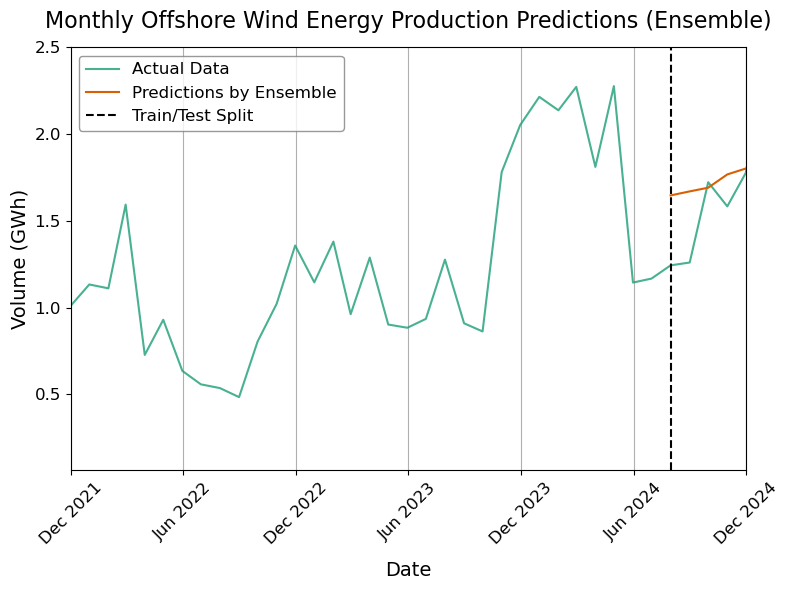

In [39]:
# Function to convert to millions
def millions(x, pos):
    return f'{x * 1e-6:.1f}'

# ===== Monthly - Offshore =====
plt.figure(figsize=(8, 6))
plt.plot(pd.to_datetime(off_df_m.index), off_df_m['volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_off_m.index), ens_pred_off_m, label='Predictions by Ensemble', color='#d95f02')
split_date = pd.to_datetime(y_test_off_m.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Monthly Offshore Wind Energy Production Predictions (Ensemble)', pad = 14, size = 16)
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GWh)', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2021-12'), pd.to_datetime('2024-12')) 
plt.ylim(top=2_500_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
plt.savefig('plots/ensemble_off_m.png', dpi=300, bbox_inches='tight')
plt.show()

### Weekly forecast

In [51]:
# Forecasting horizon
fh = ForecastingHorizon(np.arange(1, len(y_test_off_w) + 1), freq = 'W')  # 24 future weeks

# Define base forecasters
forecasters = [
    ("poly", PolynomialTrendForecaster(degree = 50)),
    ("rf", make_reduction(RandomForestRegressor(n_estimators=74, min_samples_leaf = 30, random_state = random_state), 
                          window_length=5, strategy="recursive")),
]

# Create ensemble
weights = [0.4, 0.6]
weighted_ensemble = EnsembleForecaster(
    forecasters=forecasters,
    weights=weights
)

# Fit model
start_time = time.time()
weighted_ensemble.fit(y_train_off_w, X = X_train_off_w)

# Forecast
ens_pred_off_w = weighted_ensemble.predict(fh, X = X_test_off_w)

# Evaluate
mape = mean_absolute_percentage_error(y_test_off_w, ens_pred_off_w)
print(f"MAPE: {mape:.4f}")

end_time = time.time()
print(f"Execution Time: {end_time - start_time:.4f} seconds")

print("RMSE:", mean_squared_error(y_test_off_w, ens_pred_off_w)**0.5)
print("MSE:", mean_squared_error(y_test_off_w, ens_pred_off_w))

MAPE: 0.6388
Execution Time: 0.3927 seconds
RMSE: 853630.7108154359
MSE: 728685390447.2664


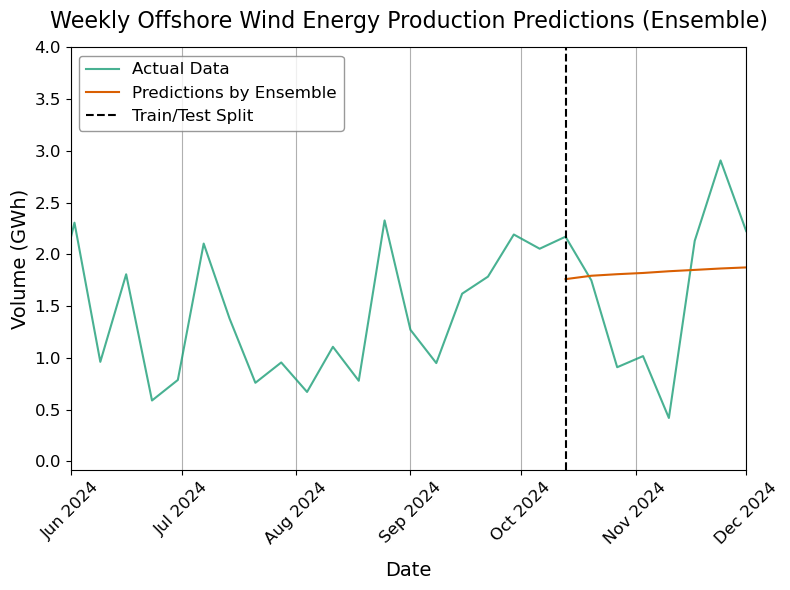

In [59]:
# ===== Weekly - Offshore =====
plt.figure(figsize=(8, 6))
plt.plot(pd.to_datetime(off_df_w.index), off_df_w['volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_off_w.index), ens_pred_off_w, label='Predictions by Ensemble', color='#d95f02')
split_date = pd.to_datetime(y_test_off_w.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Weekly Offshore Wind Energy Production Predictions (Ensemble)', pad = 14, size = 16)
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GWh)', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-06'), pd.to_datetime('2024-12')) 
plt.ylim(top=4_000_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
plt.savefig('plots/ensemble_off_w.png', dpi=300, bbox_inches='tight')
plt.show()

### Daily forecast

In [67]:
# Forecasting horizon
fh = ForecastingHorizon(np.arange(1, len(y_test_off_d) + 1), freq = 'D')  # 60 future days

# Define base forecasters
forecasters = [
    ("poly", PolynomialTrendForecaster(degree = 55)),
    ("rf", make_reduction(RandomForestRegressor(n_estimators=10, min_samples_leaf = 18, random_state = random_state), 
                          window_length = 5, strategy="recursive")),
]

# Create ensemble
weights = [0.95, 0.05]
weighted_ensemble = EnsembleForecaster(
    forecasters=forecasters,
    weights=weights
)

# Fit model
start_time = time.time()
weighted_ensemble.fit(y_train_off_d, X = X_train_off_d)

# Forecast
ens_pred_off_d = weighted_ensemble.predict(fh, X = X_test_off_d)

# Evaluate
mape = mean_absolute_percentage_error(y_test_off_d, ens_pred_off_d)
print(f"MAPE: {mape:.4f}")

end_time = time.time()
print(f"Execution Time: {end_time - start_time:.4f} seconds")

print("RMSE:", mean_squared_error(y_test_off_d, ens_pred_off_d)**0.5)
print("MSE:", mean_squared_error(y_test_off_d, ens_pred_off_d))

MAPE: 4.3973
Execution Time: 0.9223 seconds
RMSE: 1294037.7646578415
MSE: 1674533736360.663


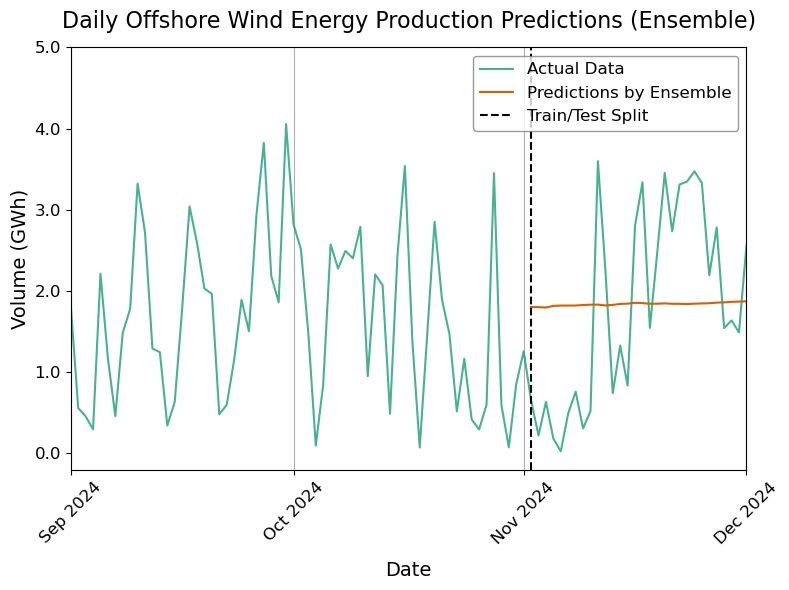

In [88]:
# ===== Daily - Offshore =====
plt.figure(figsize=(8, 6))
plt.plot(pd.to_datetime(off_df_d.index), off_df_d['volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_off_d.index), ens_pred_off_d, label='Predictions by Ensemble', color='#d95f02')
split_date = pd.to_datetime(y_test_off_d.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Daily Offshore Wind Energy Production Predictions (Ensemble)', pad = 14, size = 16)
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GWh)', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-09'), pd.to_datetime('2024-12')) 
plt.ylim(top=5_000_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
plt.savefig('plots/ensemble_off_d.png', dpi=300, bbox_inches='tight')
plt.show()

### Hourly forecast

In [81]:
# Define forecasting horizon
fh = ForecastingHorizon(np.arange(1, len(y_test_off_h) + 1), freq = 'H')

# Define base forecasters
forecasters = [
    ("poly", PolynomialTrendForecaster(degree = 56)),
    ("rf", make_reduction(RandomForestRegressor(n_estimators=100, min_samples_leaf = 10, random_state = random_state), 
                          window_length = 5, strategy="recursive")),
]

# With custom weights (must sum to 1)
weights = [0.5, 0.5]
weighted_ensemble = EnsembleForecaster(
    forecasters=forecasters,
    weights=weights
)

start_time = time.time()

# Fit the ensemble with exogenous variables
weighted_ensemble.fit(y_train_off_h, X=X_train_off_h)

# Generate forecasts
ens_pred_off_h = weighted_ensemble.predict(fh, X=X_test_off_h)

# Evaluate
mape = mean_absolute_percentage_error(y_test_off_h, ens_pred_off_h)
print(f"MAPE: {mape:.4f}")

end_time = time.time()
execution_time = end_time - start_time
print(f"Execution Time: {execution_time:.4f} seconds")
print("RMSE:", mean_squared_error(y_test_off_h, ens_pred_off_h)**0.5)
print("MSE:", mean_squared_error(y_test_off_h, ens_pred_off_h))

MAPE: 125769334629752471552.0000
Execution Time: 226.6868 seconds
RMSE: 1537748.0410328875
MSE: 2364669037700.4834


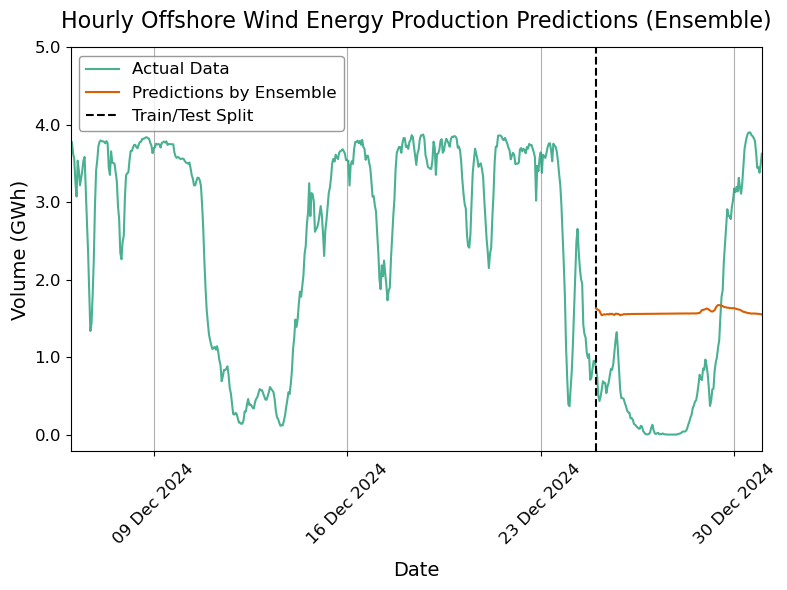

In [90]:
# ===== Hourly - Offshore =====
plt.figure(figsize=(8, 6))
plt.plot(pd.to_datetime(off_df.index), off_df['volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_off_h.index), ens_pred_off_h, label='Predictions by Ensemble', color='#d95f02')
split_date = pd.to_datetime(y_test_off_h.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Hourly Offshore Wind Energy Production Predictions (Ensemble)', pad = 14, size = 16)
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GWh)', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.xlim(pd.to_datetime('2024-12-06'), pd.to_datetime('2024-12-31')) 
plt.ylim(top=5_000_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='upper left', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
plt.savefig('plots/ensembleoff_h.png', dpi=300, bbox_inches='tight')
plt.show()


## Onshore data

### Monthly forecast

In [43]:
# Forecasting horizon
fh = ForecastingHorizon(np.arange(1, len(y_test_on_m) + 1), freq = 'M')  # 12 future months

# Define base forecasters
forecasters = [
    ("poly", PolynomialTrendForecaster(degree = 5)),
    ("rf", make_reduction(RandomForestRegressor(n_estimators = 4, min_samples_leaf = 1, random_state = random_state), 
                          window_length=2, strategy="recursive")),
]

# Create ensemble with equal weights
weights = [0.2, 0.8]
weighted_ensemble = EnsembleForecaster(
    forecasters=forecasters,
    weights=weights
)

# Fit model
start_time = time.time()
weighted_ensemble.fit(y_train_on_m, X=X_train_on_m, fh=fh)

# Forecast
ens_pred_on_m = weighted_ensemble.predict(fh, X=X_test_on_m)

# Evaluate
mape = mean_absolute_percentage_error(y_test_on_m, ens_pred_on_m)
print(f"MAPE: {mape:.4f}")

end_time = time.time()
print(f"Execution Time: {end_time - start_time:.4f} seconds")

print("RMSE:", mean_squared_error(y_test_on_m, ens_pred_on_m)**0.5)
print("MSE:", mean_squared_error(y_test_on_m, ens_pred_on_m))

MAPE: 0.1151
Execution Time: 0.0786 seconds
RMSE: 414908.78963394475
MSE: 172149303715.50504


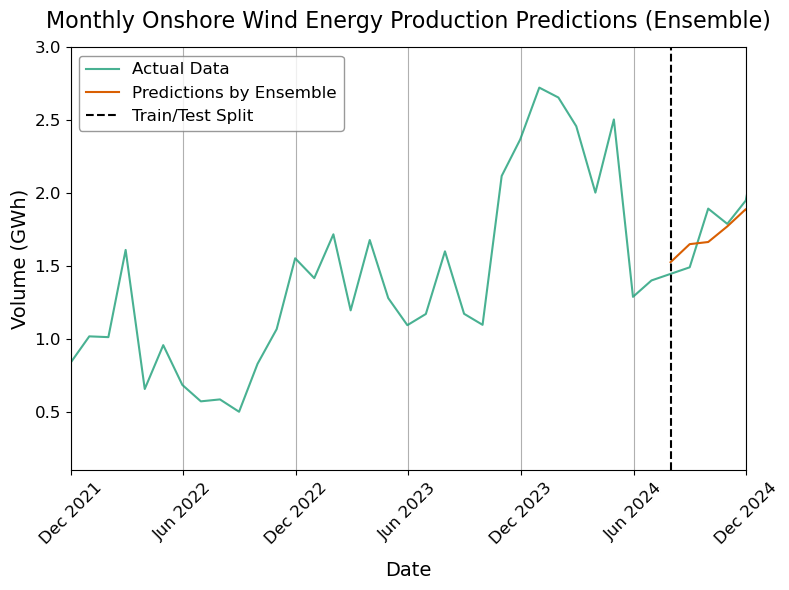

In [47]:
# Monthly onshore
plt.figure(figsize=(8, 6))
plt.plot(pd.to_datetime(on_df_m.index), on_df_m['volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_on_m.index), ens_pred_on_m, label='Predictions by Ensemble', color='#d95f02')
split_date = pd.to_datetime(y_test_on_m.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Monthly Onshore Wind Energy Production Predictions (Ensemble)', pad = 14, size = 16)
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GWh)', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2021-12'), pd.to_datetime('2024-12')) 
plt.ylim(top=3_000_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
plt.savefig('plots/ensemble_on_m.png', dpi=300, bbox_inches='tight')
plt.show()


### Weekly forecast

In [61]:
# Forecasting horizon
fh = ForecastingHorizon(np.arange(1, len(y_test_on_w) + 1), freq = 'W')  # 24 future weeks

# Define base forecasters
forecasters = [
    ("poly", PolynomialTrendForecaster(degree = 1)),
    ("rf", make_reduction(RandomForestRegressor(n_estimators=26, min_samples_leaf = 29, random_state = random_state), 
                          window_length=5, strategy="recursive")),
]

# Create ensemble
weights = [0, 1]
weighted_ensemble = EnsembleForecaster(
    forecasters=forecasters,
    weights=weights
)

# Fit model
start_time = time.time()
weighted_ensemble.fit(y_train_on_w, X = X_train_on_w)

# Forecast
ens_pred_on_w = weighted_ensemble.predict(fh, X = X_test_on_w)

# Evaluate
mape = mean_absolute_percentage_error(y_test_on_w, ens_pred_on_w)
print(f"MAPE: {mape:.4f}")

end_time = time.time()
print(f"Execution Time: {end_time - start_time:.4f} seconds")

print("RMSE:", mean_squared_error(y_test_on_w, ens_pred_on_w)**0.5)
print("MSE:", mean_squared_error(y_test_on_w, ens_pred_on_w))

MAPE: 0.6486
Execution Time: 0.2026 seconds
RMSE: 971486.9849350753
MSE: 943786961898.2433


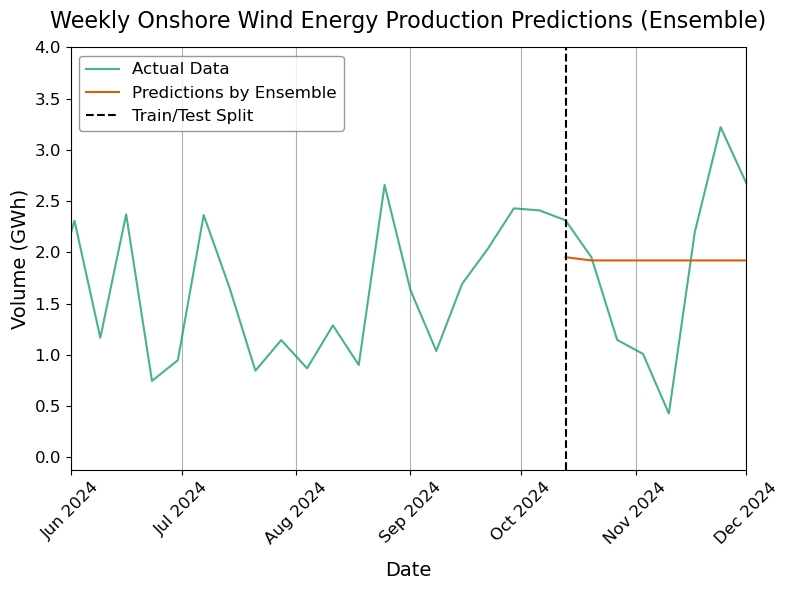

In [63]:
# ===== Weekly - Onshore =====
plt.figure(figsize=(8, 6))
plt.plot(pd.to_datetime(on_df_w.index), on_df_w['volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_on_w.index), ens_pred_on_w, label='Predictions by Ensemble', color='#d95f02')
split_date = pd.to_datetime(y_test_on_w.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Weekly Onshore Wind Energy Production Predictions (Ensemble)', pad = 14, size = 16)
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GWh)', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-06'), pd.to_datetime('2024-12')) 
plt.ylim(top=4_000_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
plt.savefig('plots/ensemble_on_w.png', dpi=300, bbox_inches='tight')
plt.show()

### Daily forecast

In [71]:
# Forecasting horizon
fh = ForecastingHorizon(np.arange(1, len(y_test_on_d) + 1), freq = 'D')  # 60 future days

# Define base forecasters
forecasters = [
    ("poly", PolynomialTrendForecaster(degree = 71)),
    ("rf", make_reduction(RandomForestRegressor(n_estimators=100, min_samples_leaf = 16, random_state = random_state), 
                          window_length = 5, strategy="recursive")),
]

# Create ensemble
weights = [1, 0]
weighted_ensemble = EnsembleForecaster(
    forecasters=forecasters,
    weights=weights
)

# Fit model
start_time = time.time()
weighted_ensemble.fit(y_train_on_d, X = X_train_on_d)

# Forecast
ens_pred_on_d = weighted_ensemble.predict(fh, X = X_test_on_d)

# Evaluate
mape = mean_absolute_percentage_error(y_test_on_d, ens_pred_on_d)
print(f"MAPE: {mape:.4f}")

end_time = time.time()
print(f"Execution Time: {end_time - start_time:.4f} seconds")

print("RMSE:", mean_squared_error(y_test_on_d, ens_pred_on_d)**0.5)
print("MSE:", mean_squared_error(y_test_on_d, ens_pred_on_d))

MAPE: 3.8757
Execution Time: 8.0459 seconds
RMSE: 1461656.880000765
MSE: 2136440834853.5703


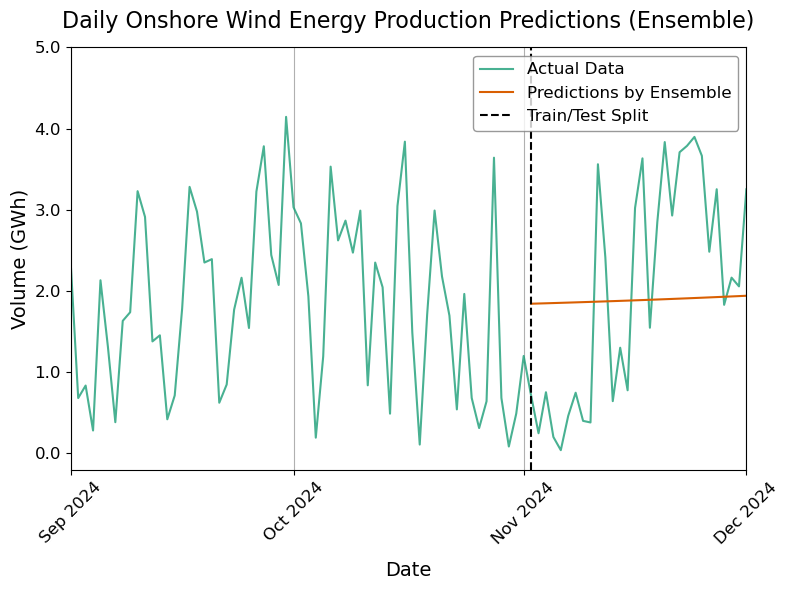

In [72]:
# ===== Daily - onshore =====
plt.figure(figsize=(8, 6))
plt.plot(pd.to_datetime(on_df_d.index), on_df_d['volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_on_d.index), ens_pred_on_d, label='Predictions by Ensemble', color='#d95f02')
split_date = pd.to_datetime(y_test_on_d.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Daily Onshore Wind Energy Production Predictions (Ensemble)', pad = 14, size = 16)
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GWh)', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-09'), pd.to_datetime('2024-12')) 
plt.ylim(top=5_000_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
plt.savefig('plots/ensemble_on_d.png', dpi=300, bbox_inches='tight')
plt.show()

### Hourly forecast

In [94]:
# Define forecasting horizon
fh = ForecastingHorizon(np.arange(1, len(y_test_on_h) + 1), freq = 'H')

# Define base forecasters
forecasters = [
    ("poly", PolynomialTrendForecaster(degree = 56)),
    ("rf", make_reduction(RandomForestRegressor(n_estimators=50, min_samples_leaf = 30, random_state = random_state), 
                          window_length = 5, strategy="recursive")),
]

# With custom weights (must sum to 1)
weights = [0.3, 0.7]
weighted_ensemble = EnsembleForecaster(
    forecasters=forecasters,
    weights=weights
)

start_time = time.time()

# Fit the ensemble with exogenous variables
weighted_ensemble.fit(y_train_on_h, X=X_train_on_h)

# Generate forecasts
ens_pred_on_h = weighted_ensemble.predict(fh, X=X_test_on_h)

# Evaluate
mape = mean_absolute_percentage_error(y_test_on_h, ens_pred_on_h)
print(f"MAPE: {mape:.4f}")

end_time = time.time()
execution_time = end_time - start_time
print(f"Execution Time: {execution_time:.4f} seconds")
print("RMSE:", mean_squared_error(y_test_on_h, ens_pred_on_h)**0.5)
print("MSE:", mean_squared_error(y_test_on_h, ens_pred_on_h))

MAPE: 470837245456448618496.0000
Execution Time: 123.6115 seconds
RMSE: 1625782.428084151
MSE: 2643168503467.1973


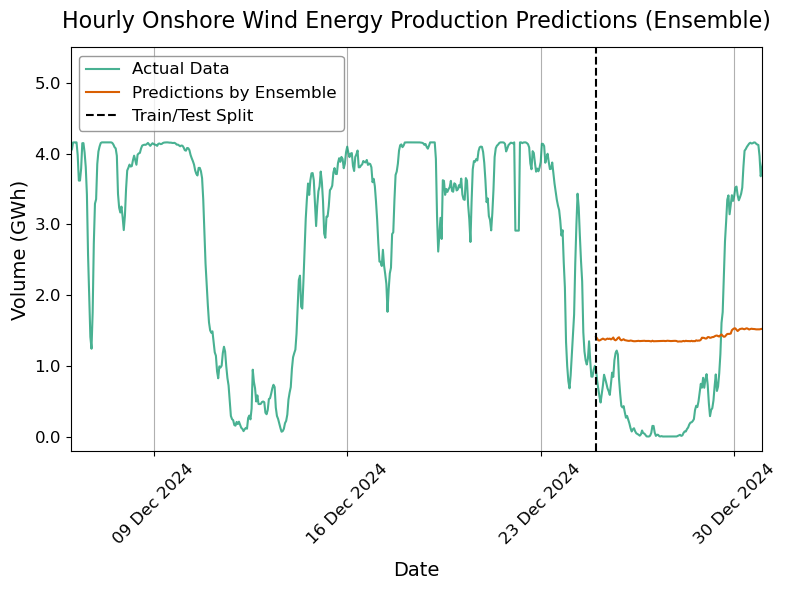

In [100]:
# ===== Hourly - onshore =====
plt.figure(figsize=(8, 6))
plt.plot(pd.to_datetime(on_df.index), on_df['volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_on_h.index), ens_pred_on_h, label='Predictions by Ensemble', color='#d95f02')
split_date = pd.to_datetime(y_test_on_h.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Hourly Onshore Wind Energy Production Predictions (Ensemble)', pad = 14, size = 16)
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GWh)', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.xlim(pd.to_datetime('2024-12-06'), pd.to_datetime('2024-12-31')) 
plt.ylim(top=5_500_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='upper left', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
plt.savefig('plots/ensemble_on_h.png', dpi=300, bbox_inches='tight')
plt.show()
